**实验目标：**

通过本实验，你将深入了解和实践说话人识别技术，并掌握利用声音特征进行有效说话人识别的基本方法，了解不同特征和模型对识别准确率的影响。

实验的核心目标是使用TIMIT数据集来训练一个说话人识别系统，涵盖数据预处理、特征提取、模型训练和评估等关键步骤。


**实验方法：**

**1. 数据预处理和划分(可选)：**
  - 数据集下载地址（4月17日前有效）：https://f.ws59.cn/f/du8yd2536vl
  - 为了方便大家，我们提供了划分好的TIMIT数据集结构，当然你也可以根据需求自行划分该数据集。
  - 为简化难度，我们排除了SA的两个方言句子，并在剩余的8个句子中选取了SX的5个句子和SI的1个句子作为训练集，SI的另外2个句子作为测试集。
  - 该链接下载的数据集只保留了音频文件，完整数据集（包含音频对应文本、标注等信息）可参见备注链接下载。
  
**2. 特征提取：**
  - 学习并实现包括但不限于MFCC特征等特征的提取，探索声音信号的频率和时间特性。
  - 鼓励尝试和比较其他特征提取方法，例如LPCC或声谱图特征，以理解不同特征对识别性能的影响。
  
**3. 模型选择和训练：**
  - 探索并选择适合的分类器和模型进行说话人识别，如GMM、Softmax分类器或深度学习模型。
  - 实现模型训练流程，使用训练集数据训练模型。
  
**4. 评估和分析：**
  - 使用准确率作为主要的评价指标在测试集上评估模型性能。
  - 对比不同特征和模型的性能，分析其对说话人识别准确率的影响。
  - 可视化不同模型的识别结果和错误率，讨论可能的改进方法。

**实验要求：**
  - 1.选择并实现至少一种特征的提取，并鼓励尝试其他特征提取方法。
  - 2.选择并实现至少一种分类器或模型进行说话人识别，并使用准确率评估指标评估其性能。
  - 3.通过实验对比、分析和可视化，撰写详细的实验报告，包括实验目的、实验方法、结果分析和结论。
  - 4.实验报告应以清晰、逻辑性强的形式呈现，图表和结果应清楚明了。

**其他说明：**
  - 实验的最终打分环节会看识别性能，会对原理和实现代码部分做抽查提问，综合评定成绩。
  - 我们**鼓励做原创性探索**，即使性能不是很好，但有创新性、有价值、有意义的探索和尝试会有额外加分。
  - 原数完整据集下载地址：https://drive.google.com/file/d/180mSIiXN9RVDV2Xn1xcWNkMRm5J5MjN4/view?usp=sharing \
    或国内访问地址（4月17日前有效）：https://f.ws59.cn/f/du8xu130kba

## 1. 实验准备

In [1]:
# 1. 导入必要的库
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. 数据预处理

In [2]:
# 2. 数据预处理
def load_json_data(json_file):
    """加载JSON格式的数据集"""
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

# 加载训练集和测试集
train_data = load_json_data('trainset.json')
test_data = load_json_data('testset.json')

- 数据集信息展示

In [3]:
# 打印数据集信息
print(f"训练集样本数: {len(train_data)}")
print(f"测试集样本数: {len(test_data)}")

# 查看数据样例
print("\n训练集样例:")
print(train_data[0])

# 统计说话人和方言区域的分布
train_speakers = set([item['speaker_id'] for item in train_data])
test_speakers = set([item['speaker_id'] for item in test_data])
train_dialects = set([item['dialect_region'] for item in train_data])

print(f"\n训练集包含 {len(train_speakers)} 位说话人")
print(f"测试集包含 {len(test_speakers)} 位说话人")
print(f"数据集包含 {len(train_dialects)} 个方言区域")

# 创建说话人ID到索引的映射
all_speakers = sorted(list(train_speakers.union(test_speakers)))
speaker_to_idx = {speaker: idx for idx, speaker in enumerate(all_speakers)}
idx_to_speaker = {idx: speaker for speaker, idx in speaker_to_idx.items()}

print(f"\n共有 {len(speaker_to_idx)} 位说话人")


训练集样本数: 2772
测试集样本数: 924

训练集样例:
{'audio_filepath': './Dataset/TRAIN/DR1/FCJF0/SI648_.wav', 'dialect_region': 'DR1', 'gender': 'F', 'speaker_id': 'CJF0'}

训练集包含 462 位说话人
测试集包含 462 位说话人
数据集包含 8 个方言区域

共有 462 位说话人


- 数据集信息可视化

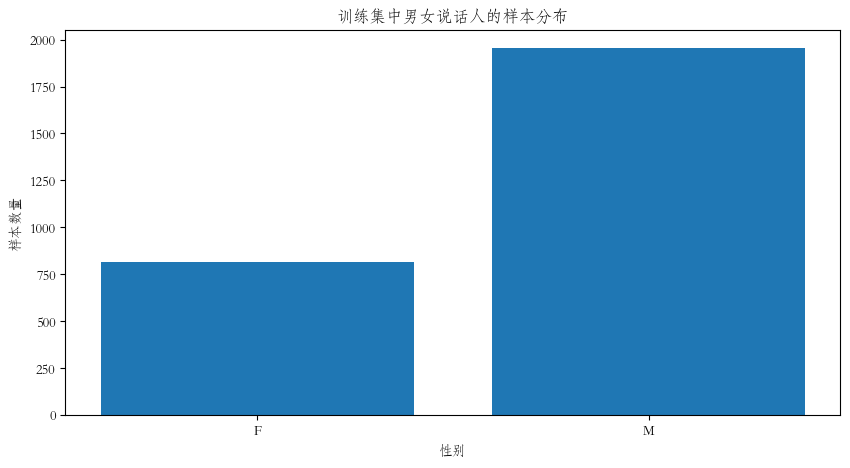


显示样本音频: ./Dataset/TRAIN/DR1/FCJF0/SI648_.wav


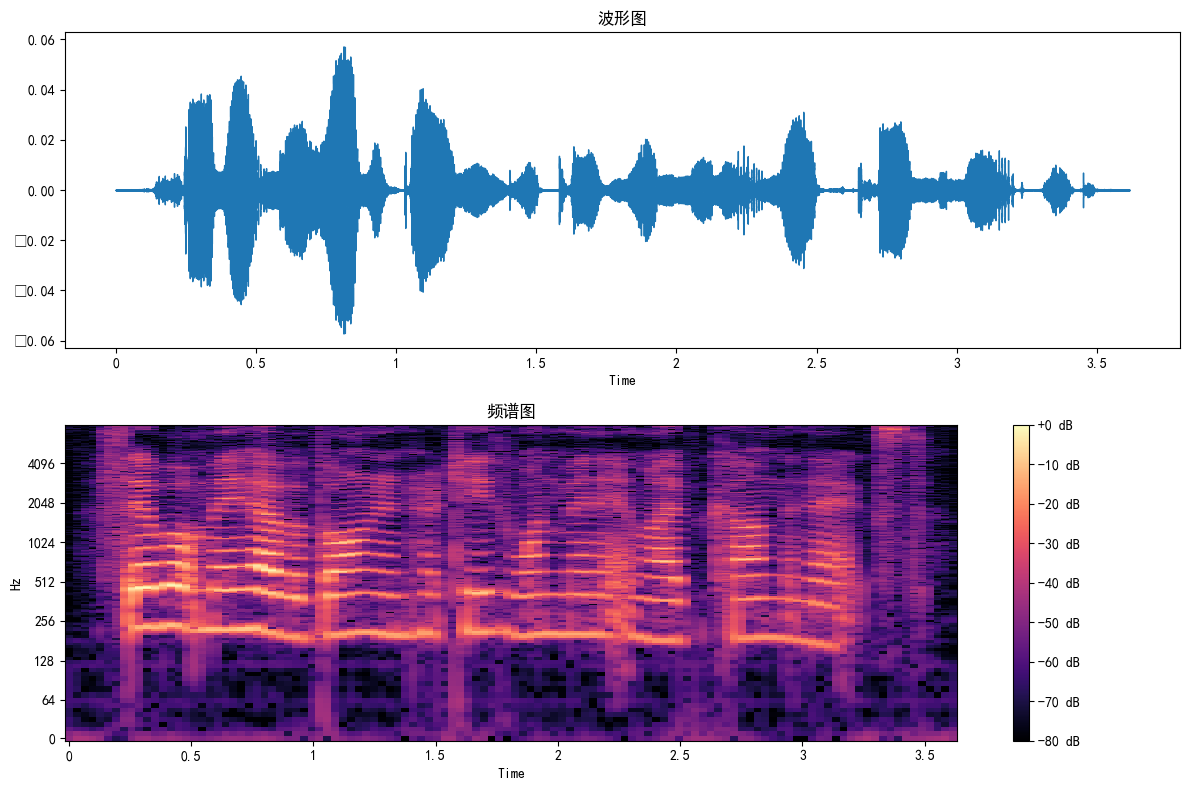

In [5]:
# 可视化数据集中的音频样本分布
train_gender_counts = {"F": 0, "M": 0}
for item in train_data:
    train_gender_counts[item['gender']] += 1

plt.figure(figsize=(10, 5))
plt.bar(train_gender_counts.keys(), train_gender_counts.values())
plt.title('训练集中男女说话人的样本分布')
plt.xlabel('性别')
plt.ylabel('样本数量')
plt.show()

# 可视化一个音频样本的波形
def plot_audio_sample(audio_path):
    """绘制音频波形和频谱图"""
    y, sr = librosa.load(audio_path, sr=None)
    
    plt.rcParams['font.family'] = 'SimHei'
    plt.figure(figsize=(12, 8))
    
    # 波形图
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title('波形图')
    
    # 频谱图
    plt.subplot(2, 1, 2)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('频谱图')
    
    plt.tight_layout()
    plt.show()

# 展示一个样本的波形和频谱，以确认加载成功
if len(train_data) > 0:
    sample_path = train_data[0]['audio_filepath']
    print(f"\n显示样本音频: {sample_path}")
    plot_audio_sample(sample_path)

## 3. 特征提取 —— MFCC梅尔频率倒谱系数
是一种用来表达语音的声音特征的方法。

- 添加了二阶差分 <br>

| 如果只看 MFCC | 加入 一阶差分 和 二阶差分 |
|-----------|--------------|
| 就像拍了一张语音的“快照”，知道它此刻长什么样 | 就像拍了“连续剧”，能看到语音在怎么变化 |
| 不容易区分“啊”和“呀”等发音，因为它们瞬间特征差不多 | 更容易捕捉“啊变成呀”的过程，区别更明显 |
| 缺乏上下文，模型更容易迷糊 | 有时间上下文信息，模型更聪明 |


In [6]:
# 3. 特征提取 - MFCC (Mel-Frequency Cepstral Coefficients)
def extract_mfcc_features(audio_path, n_mfcc=20):
    """
    从音频文件中提取MFCC特征
    
    参数:
    audio_path: 音频文件路径
    n_mfcc: MFCC系数数量
    
    返回:
    mfccs: MFCC特征矩阵 (时间帧数 × MFCC系数数)
    """
    y, sr = librosa.load(audio_path, sr=None)
    
    # 提取MFCC特征
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc) # libsora生成的 mfccs 的 shape 是 (n_mfcc, time_frames)
    
    # 使用deltas和delta-deltas增强特征
    delta_mfccs = librosa.feature.delta(mfccs) # 一阶差分会比较当前帧和前后帧的值 → 得到一个“变化趋势” ( 看“数值涨了还是跌了”)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2) # 二阶差分 相当于"加速度”，能识别更精细的语音变化，比如发音拐点、音调突然变化等。(看“涨得快不快”)
    
    # 通过在特征维度concat合并原始MFCC与其一阶和二阶差分结果
    combined_mfccs = np.concatenate((mfccs, delta_mfccs, delta2_mfccs), axis=0) # 这里设置axis=0 因为需要在n_mfcc维度拼接，而非time_frames维度
    
    # 转置为时间帧 × 特征维度的格式
    return combined_mfccs.T

# 可视化MFCC特征
def visualize_mfcc(mfccs, title="MFCC特征"):
    """可视化MFCC特征矩阵"""
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(mfccs.T, x_axis='time') # librosa.display.specshow 函数期望输入的维度形状是 (n_mfcc, time_frames) ,所以要转置
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.ylabel("MFCC系数索引")
    plt.xlabel("时间 (秒)")
    plt.tight_layout()
    plt.show()

# 为训练集和测试集提取MFCC特征
def prepare_features_for_single_gmm(data, n_mfcc=20):
    """
    为单一GMM模型准备特征集和标签集
    
    返回:
    features: 所有样本的特征矩阵
    labels: 对应的说话人标签
    """
    features = []
    labels = []
    
    for item in data:
        speaker_id = item['speaker_id']
        # 提取特征
        mfccs = extract_mfcc_features(item['audio_filepath'], n_mfcc)
        features.append(mfccs)
        # 为每一帧都添加相同的说话人标签
        labels.extend([speaker_id] * mfccs.shape[0])
    
    # 合并所有说话人的特征
    features = np.vstack(features)
    labels = np.array(labels)
    
    return features, labels

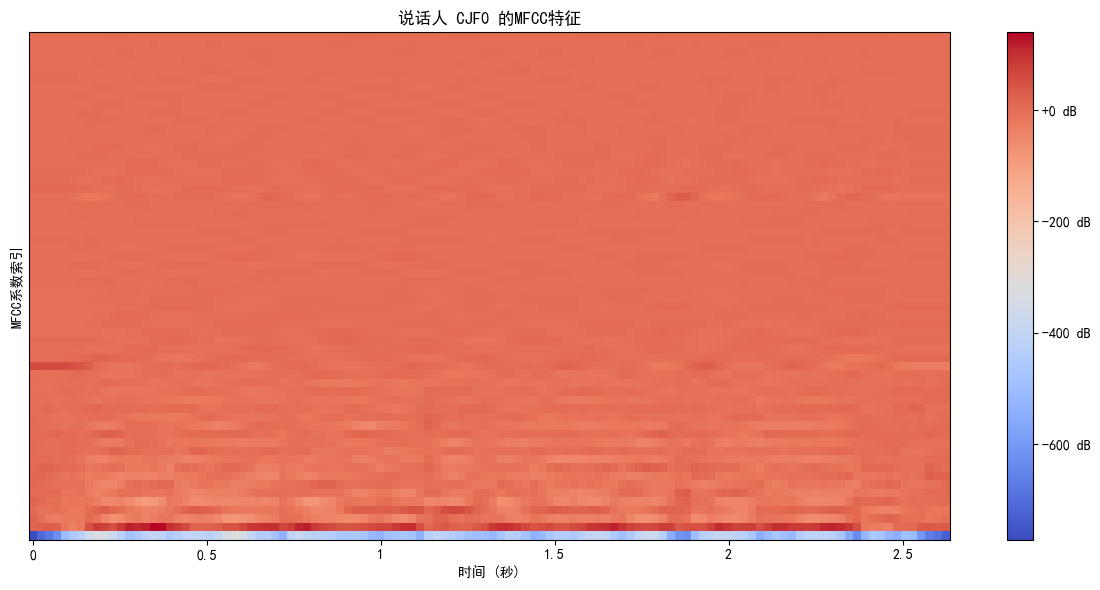

正在为训练集提取MFCC特征...
正在为测试集提取MFCC特征...
特征提取完成!


In [7]:
# 使用训练集样本可视化MFCC特征
if len(train_data) > 0:
    sample_path = train_data[0]['audio_filepath']
    sample_speaker = train_data[0]['speaker_id']
    
    # 提取并显示MFCC特征
    mfccs = extract_mfcc_features(sample_path) 
    visualize_mfcc(mfccs, f"说话人 {sample_speaker} 的MFCC特征")

print("正在为训练集提取MFCC特征...")
train_features, train_labels = prepare_features_for_single_gmm(train_data)

print("正在为测试集提取MFCC特征...")
test_features, test_labels = prepare_features_for_single_gmm(test_data)

print("特征提取完成!")

- MFCC特征图图像解读：
- 语音片段 vs 静音片段<br>
有语音的时间段：图上出现明显的颜色波动、斑块，像条纹或带状结构。
<br>
静音的地方：颜色趋于一致、平滑，整段暗蓝，没有明显波动。<br>

- 元音 vs 辅音<br>
元音：比较持续，颜色块宽大，变化慢。
<br>
辅音（尤其是爆破音、摩擦音）：突变明显，看起来像一条一条的窄条纹，瞬间颜色突变。<br>

- 说话内容越丰富，图案越复杂<br>
如果有人在短时间说了很多话，会看到图上花纹密集、频繁变化。
<br>
如果是读数字或短句，变化会更规律。<br>

## 4. 模型选择和训练 - GMM (Gaussian Mixture Model)

In [8]:
# 4. 模型选择和训练 - GMM (Gaussian Mixture Model)
from sklearn.mixture import GaussianMixture

def train_single_gmm(features, n_components):
    """
    训练单一GMM模型
    
    参数:
    features: 所有说话人的特征矩阵
    n_components: 高斯混合成分数量
    
    返回:
    gmm: 训练好的GMM模型
    """
    print("训练单一GMM模型...")
    
    # 创建并训练GMM模型
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='diag',
    )
    
    gmm.fit(features)
    return gmm


In [ ]:
# 训练GMM模型
print("开始GMM模型训练...")
n_components = 128 # 高斯混合成分数量
single_gmm  = train_single_gmm(train_features, n_components)
print("单一GMM模型训练完成!")

开始GMM模型训练...
训练单一GMM模型...
单一GMM模型训练完成!


## 5. 评价指标(准确率Accuracy)

In [14]:
# 5. 评估和分析
def test_single_gmm(gmm, test_features, speaker_mapping):
    """
    使用单一GMM模型进行测试
    
    参数:
    gmm: 训练好的GMM模型
    test_features: 测试特征矩阵
    speaker_mapping: 将GMM成分映射到说话人ID的字典
    
    返回:
    predictions: 预测的说话人ID列表
    """
    # 预测每个样本属于哪个高斯成分
    component_predictions = gmm.predict(test_features)
    
    # 将成分预测转换为说话人ID
    speaker_predictions = [speaker_mapping.get(comp, "unknown") for comp in component_predictions]
    
    return speaker_predictions

def evaluate_single_gmm(gmm, test_data, train_features, train_labels, n_mfcc=20):
    """
    评估单一GMM模型在测试集上的性能
    
    返回:
    true_speakers: 真实说话人ID列表
    pred_speakers: 预测说话人ID列表
    accuracy: 准确率
    """
    # 创建成分到说话人的映射
    component_predictions = gmm.predict(train_features)
    component_to_speaker = {}
    
    # 统计每个成分最常对应的说话人
    for component, speaker in zip(component_predictions, train_labels):
        if component not in component_to_speaker:
            component_to_speaker[component] = {}
        if speaker not in component_to_speaker[component]:
            component_to_speaker[component][speaker] = 0
        component_to_speaker[component][speaker] += 1
    
    # 为每个成分选择最常见的说话人
    for component in component_to_speaker:
        component_to_speaker[component] = max(component_to_speaker[component].items(),
                                             key=lambda x: x[1])[0]
    
    # 处理测试数据
    true_speakers = []
    pred_speakers = []
    
    for item in test_data:
        true_speaker = item['speaker_id']
        features = extract_mfcc_features(item['audio_filepath'], n_mfcc)
        
        # 预测成分
        component_preds = gmm.predict(features)
        
        # 计算最常预测的说话人
        speaker_votes = {}
        for comp in component_preds:
            speaker = component_to_speaker.get(comp, "unknown")
            if speaker not in speaker_votes:
                speaker_votes[speaker] = 0
            speaker_votes[speaker] += 1
        
        # 选择投票最多的说话人
        predicted_speaker = max(speaker_votes.items(), key=lambda x: x[1])[0]
        
        true_speakers.append(true_speaker)
        pred_speakers.append(predicted_speaker)
    
    # 计算准确率
    accuracy = sum(1 for t, p in zip(true_speakers, pred_speakers) if t == p) / len(true_speakers)
    
    return true_speakers, pred_speakers, accuracy

# 评估模型性能
print("评估单一GMM模型性能...")
true_speakers, pred_speakers, accuracy = evaluate_single_gmm(
    single_gmm, test_data, train_features, train_labels)
print(f"单一GMM模型准确率: {accuracy:.4f}")

评估单一GMM模型性能...
单一GMM模型准确率: 0.0271


-高斯混合成分数量n_components对单一GMM模型准确率有极大影响

- n_components=8 , acc = 0.0061
- n_components=16, acc = 0.0091
- n_components=128, acc = 0.0271

理论上应该至少为每个说话人分配8个高斯混合成分，即 n_components = len(set(train_labels)) * 8 但计算量太大 内存空间不够

##  6. 分析和可视化


GMM模型分类报告:
              precision    recall  f1-score   support

        ABC0       0.00      0.00      0.00         2
        ADC0       0.00      0.00      0.00         2
        ADD0       0.00      0.00      0.00         2
        AEB0       0.00      0.00      0.00         2
        AEM0       0.00      0.00      0.00         2
        AEO0       0.00      0.00      0.00         2
        AFM0       0.00      0.00      0.00         2
        AJP0       0.00      0.00      0.00         2
        AJW0       0.00      0.00      0.00         2
        AKB0       0.00      0.00      0.00         2
        AKR0       0.00      0.00      0.00         2
        ALK0       0.00      0.00      0.00         2
        ALR0       0.00      0.00      0.00         2
        APB0       0.00      0.00      0.00         2
        APV0       0.00      0.00      0.00         2
        ARC0       0.00      0.00      0.00         2
        ARW0       0.00      0.00      0.00         2
        BAR0   

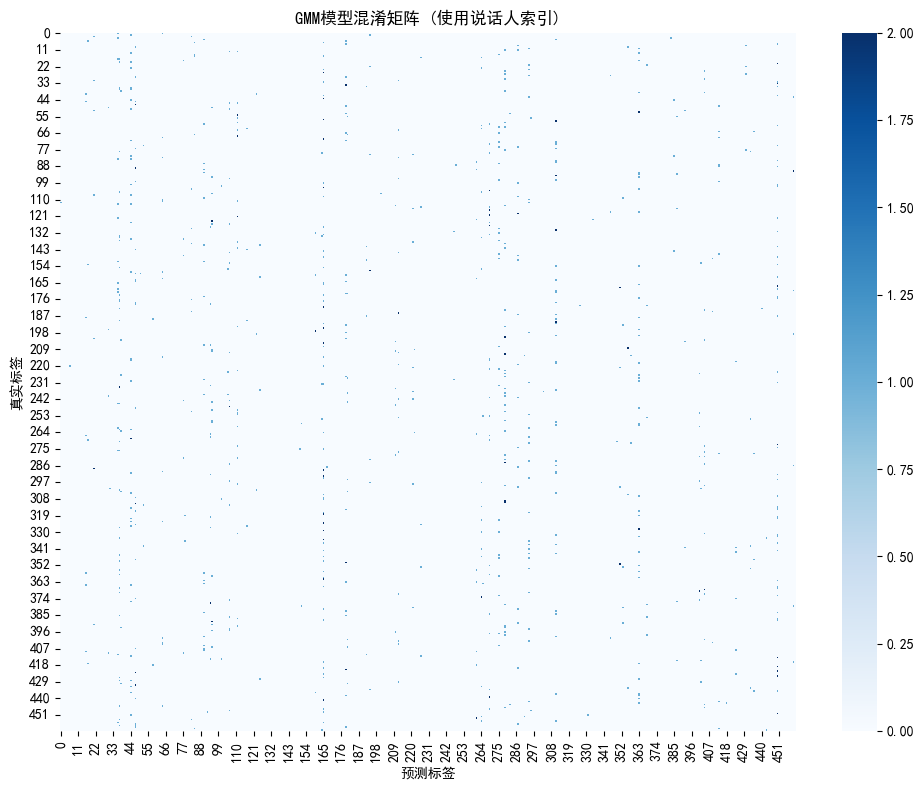

In [15]:
# 可视化混淆矩阵
def plot_confusion_matrix(true_labels, pred_labels):
    """绘制混淆矩阵"""
    # 为每个说话人分配数字ID
    unique_speakers = sorted(set(true_labels).union(set(pred_labels)))
    speaker_to_id = {speaker: i for i, speaker in enumerate(unique_speakers)}
    
    # 转换为数字ID
    true_ids = [speaker_to_id[speaker] for speaker in true_labels]
    pred_ids = [speaker_to_id[speaker] for speaker in pred_labels]
    
    # 计算混淆矩阵
    n_speakers = len(unique_speakers)
    cm = np.zeros((n_speakers, n_speakers))
    
    for t, p in zip(true_ids, pred_ids):
        cm[t, p] += 1
    
    # 创建带有标签的DataFrame
    if n_speakers <= 15:  # 如果说话人数量较少，使用原始标签
        df_cm = pd.DataFrame(cm, index=unique_speakers, columns=unique_speakers)
        title = 'GMM模型混淆矩阵'
    else:  # 对于大量说话人，使用数字索引
        df_cm = pd.DataFrame(cm)
        title = 'GMM模型混淆矩阵 (使用说话人索引)'
    
    # 绘制混淆矩阵
    plt.figure(figsize=(10, 8))
    
    # 如果说话人数量很多，使用更紧凑的热图而不是带注释的版本
    if n_speakers > 40:
        sns.heatmap(df_cm, cmap='Blues')
    else:
        # 对于中等数量的说话人，使用带数值的热图
        sns.heatmap(df_cm, annot=(n_speakers <= 15), fmt='g' if n_speakers <= 15 else '.2f', 
                   cmap='Blues')
    
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 输出分类报告
print("\nGMM模型分类报告:")
print(classification_report(true_speakers, pred_speakers))

# 绘制混淆矩阵
plot_confusion_matrix(true_speakers, pred_speakers)

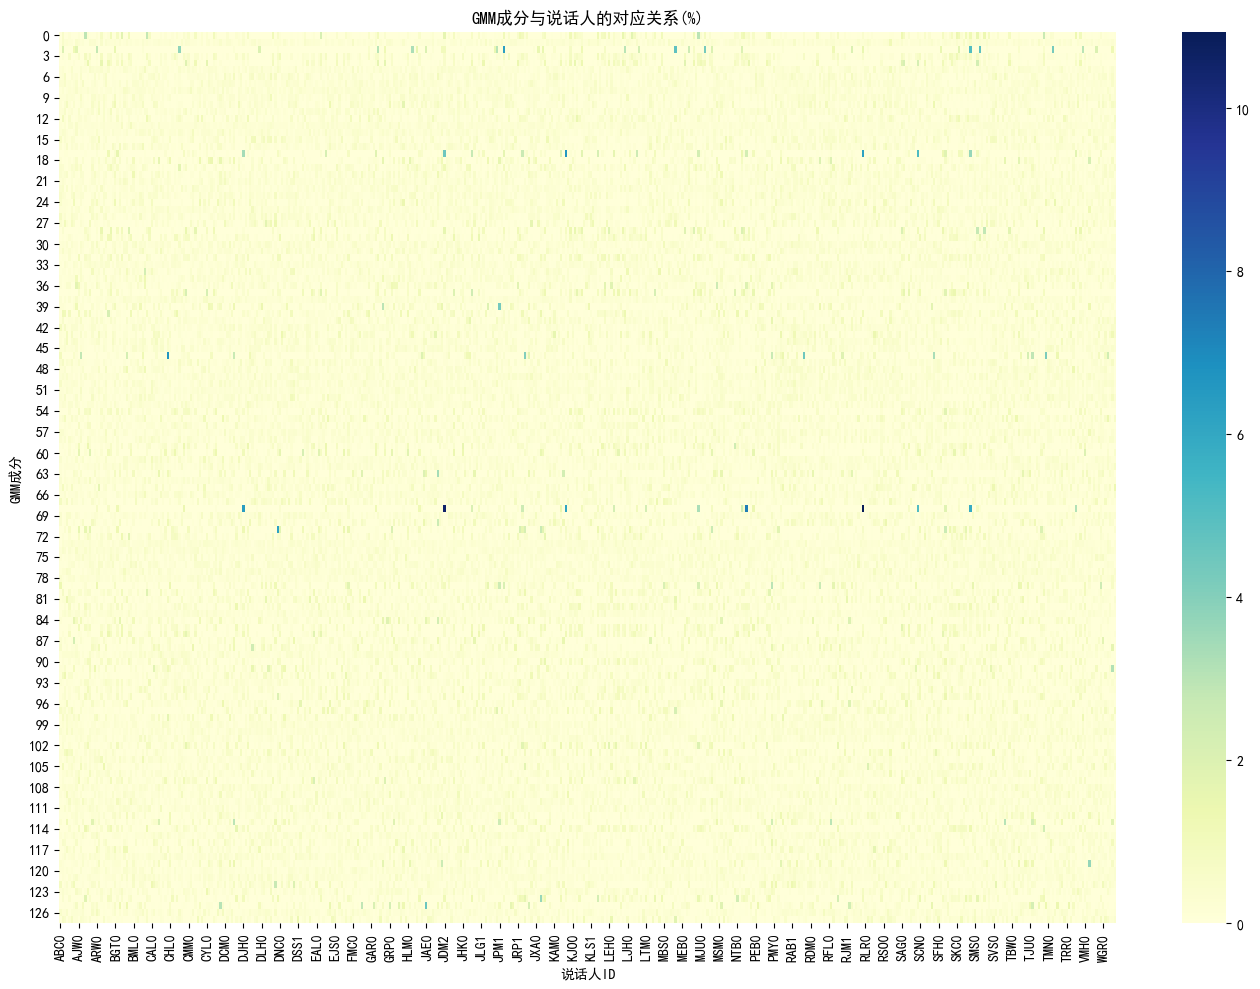

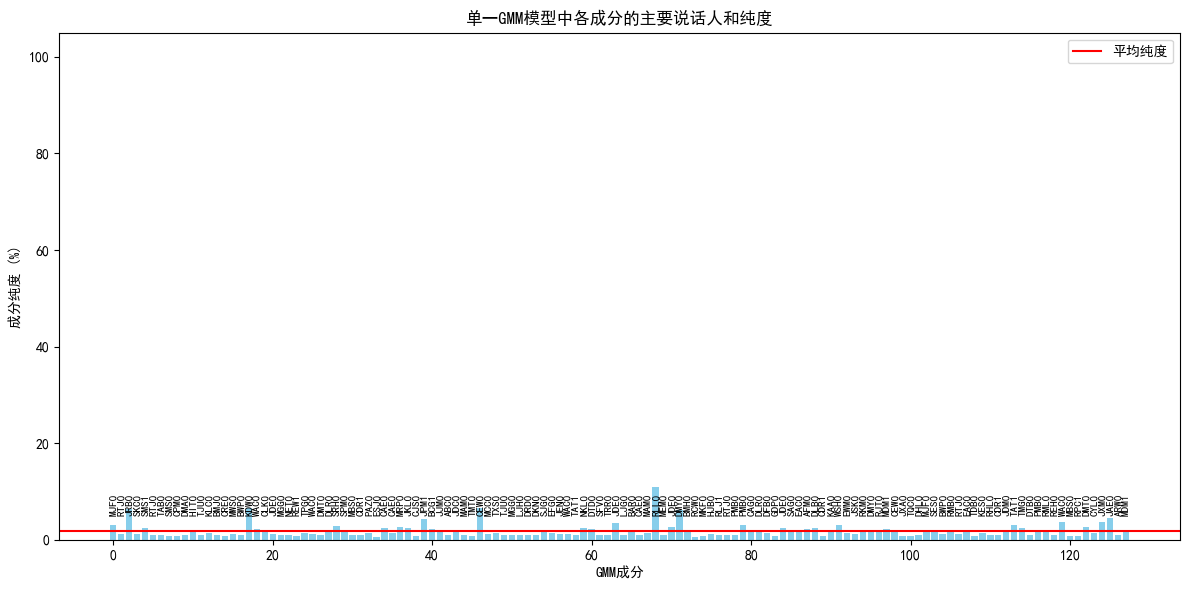

In [18]:
# 可视化单一GMM模型的成分分布
def visualize_gmm_components(gmm, train_features, train_labels):
    """可视化单一GMM模型中各成分与说话人的对应关系"""
    # 获取每个样本的成分归属
    component_predictions = gmm.predict(train_features)
    
    # 创建成分-说话人映射统计
    component_speaker_counts = {}
    for component, speaker in zip(component_predictions, train_labels):
        if component not in component_speaker_counts:
            component_speaker_counts[component] = {}
        if speaker not in component_speaker_counts[component]:
            component_speaker_counts[component][speaker] = 0
        component_speaker_counts[component][speaker] += 1
    
    # 转换为DataFrame用于可视化
    data = []
    for component, speaker_counts in component_speaker_counts.items():
        total = sum(speaker_counts.values())
        for speaker, count in speaker_counts.items():
            data.append({
                'Component': component,
                'Speaker': speaker,
                'Percentage': (count / total) * 100
            })
    
    df = pd.DataFrame(data)
    
    # 绘制热图
    pivot_table = df.pivot_table(index='Component', columns='Speaker', values='Percentage', fill_value=0)
    plt.figure(figsize=(14, 10))
    sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)
    plt.title('GMM成分与说话人的对应关系(%)')
    plt.xlabel('说话人ID')
    plt.ylabel('GMM成分')
    plt.tight_layout()
    plt.show()
    
    # 绘制主要成分分配
    main_assignments = {}
    for component, speaker_counts in component_speaker_counts.items():
        main_speaker = max(speaker_counts.items(), key=lambda x: x[1])[0]
        main_count = speaker_counts[main_speaker]
        total = sum(speaker_counts.values())
        purity = (main_count / total) * 100
        main_assignments[component] = (main_speaker, purity)
    
    # 可视化每个成分的主要说话人和纯度
    components = list(main_assignments.keys())
    speakers = [main_assignments[c][0] for c in components]
    purities = [main_assignments[c][1] for c in components]
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(components, purities, color='skyblue')
    plt.axhline(y=np.mean(purities), color='r', linestyle='-', label='平均纯度')
    
    # 在每个柱上标注说话人ID
    for i, (bar, speaker) in enumerate(zip(bars, speakers)):
        plt.text(bar.get_x() + bar.get_width()/2, 5, speaker, 
                 ha='center', va='bottom', rotation=90, fontsize=8)
    
    plt.xlabel('GMM成分')
    plt.ylabel('成分纯度 (%)')
    plt.title('单一GMM模型中各成分的主要说话人和纯度')
    plt.ylim(0, 105)
    plt.legend()
    plt.tight_layout()
    plt.show()

visualize_gmm_components(single_gmm, train_features, train_labels)

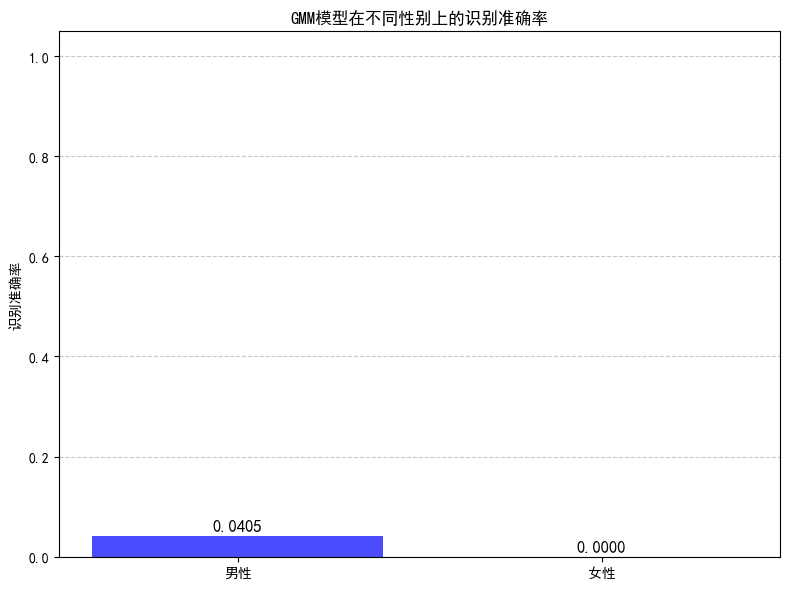

<Figure size 1000x800 with 0 Axes>

In [20]:
# 分析性别因素对识别准确率的影响
def analyze_gender_impact(true_speakers, pred_speakers):
    """分析说话人性别对GMM模型性能的影响"""
    # 从说话人ID中提取性别信息（假设第一个字符是'F'表示女性，'M'表示男性）
    gender_dict = {}
    for speaker in set(true_speakers):
        gender_dict[speaker] = speaker[0] if speaker[0] in ['F', 'M'] else 'U'
    
    # 按性别分组计算准确率
    male_indices = [i for i, spk in enumerate(true_speakers) if gender_dict.get(spk) == 'M']
    female_indices = [i for i, spk in enumerate(true_speakers) if gender_dict.get(spk) == 'F']
    
    # 计算每个性别的准确率
    male_accuracy = 0
    if male_indices:
        male_true = [true_speakers[i] for i in male_indices]
        male_pred = [pred_speakers[i] for i in male_indices]
        male_accuracy = np.mean(np.array(male_true) == np.array(male_pred))
    
    female_accuracy = 0
    if female_indices:
        female_true = [true_speakers[i] for i in female_indices]
        female_pred = [pred_speakers[i] for i in female_indices]
        female_accuracy = np.mean(np.array(female_true) == np.array(female_pred))
    
    # 绘制性别对比图
    plt.figure(figsize=(8, 6))
    plt.bar(['男性', '女性'], [male_accuracy, female_accuracy], color=['blue', 'red'], alpha=0.7)
    
    # 添加准确率标签
    plt.text(0, male_accuracy + 0.01, f'{male_accuracy:.4f}', ha='center', fontsize=12)
    plt.text(1, female_accuracy + 0.01, f'{female_accuracy:.4f}', ha='center', fontsize=12)
    
    plt.ylim(0, 1.05)
    plt.ylabel('识别准确率')
    plt.title('GMM模型在不同性别上的识别准确率')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 分析性别间的混淆情况
    errors = [(true, pred) for true, pred in zip(true_speakers, pred_speakers) if true != pred]
    
    gender_confusion = {
        'MM': 0,  # 男性识别为男性(但不同人)
        'MF': 0,  # 男性错误识别为女性
        'FM': 0,  # 女性错误识别为男性
        'FF': 0   # 女性识别为女性(但不同人)
    }
    
    for true, pred in errors:
        true_gender = gender_dict.get(true, 'U')
        pred_gender = gender_dict.get(pred, 'U')
        
        if true_gender in 'MF' and pred_gender in 'MF':
            gender_confusion[true_gender + pred_gender] += 1
    
    # 绘制性别混淆饼图
    plt.figure(figsize=(10, 8))
    labels = ['男性→其他男性', '男性→女性', '女性→男性', '女性→其他女性']
    sizes = [gender_confusion['MM'], gender_confusion['MF'], 
             gender_confusion['FM'], gender_confusion['FF']]
    
    # # 检查是否有数据
    # if sum(sizes) > 0:
    #     plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, 
    #             colors=['lightblue', 'lightgreen', 'salmon', 'khaki'])
    #     plt.axis('equal')
    #     plt.title('GMM模型性别相关的错误分布')
    #     plt.tight_layout()
    #     plt.show()

# 分析性别因素影响
analyze_gender_impact(true_speakers, pred_speakers)

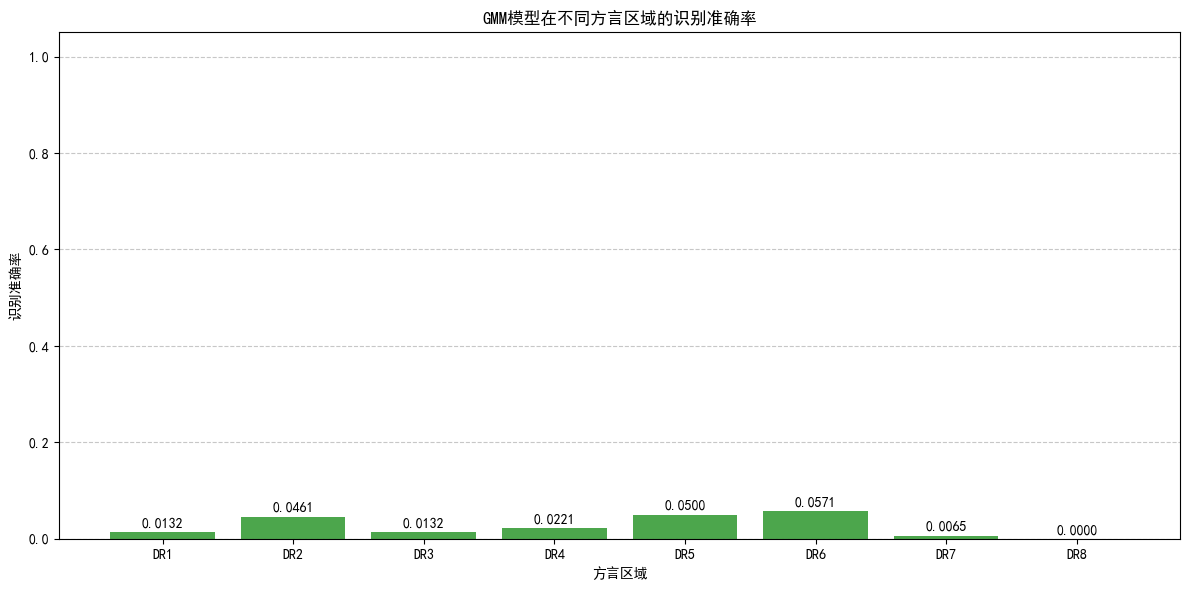

In [21]:
# 分析方言区域对识别准确率的影响
def analyze_dialect_impact(true_speakers, pred_speakers):
    """分析方言区域对GMM模型性能的影响"""
    # 从说话人文件路径中提取方言区域信息
    dialect_dict = {}
    for speaker in set(true_speakers):
        # 在实际代码中，你需要根据数据结构获取方言信息
        # 这里假设我们已经有这个信息
        for item in test_data:
            if item['speaker_id'] == speaker:
                dialect_dict[speaker] = item['dialect_region']
                break
    
    # 按方言区域分组计算准确率
    dialect_regions = sorted(set(dialect_dict.values()))
    dialect_accuracies = {}
    
    for dialect in dialect_regions:
        dialect_indices = [i for i, spk in enumerate(true_speakers) if dialect_dict.get(spk) == dialect]
        
        if not dialect_indices:
            continue
            
        true_dialect = [true_speakers[i] for i in dialect_indices]
        pred_dialect = [pred_speakers[i] for i in dialect_indices]
        
        accuracy = np.mean(np.array(true_dialect) == np.array(pred_dialect))
        dialect_accuracies[dialect] = accuracy
    
    # 绘制方言区域准确率条形图
    plt.figure(figsize=(12, 6))
    regions = list(dialect_accuracies.keys())
    accuracies = list(dialect_accuracies.values())
    
    plt.bar(regions, accuracies, color='green', alpha=0.7)
    
    # 添加准确率标签
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
    
    plt.ylim(0, 1.05)
    plt.xlabel('方言区域')
    plt.ylabel('识别准确率')
    plt.title('GMM模型在不同方言区域的识别准确率')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 分析方言区域影响
analyze_dialect_impact(true_speakers, pred_speakers)

## 7. 结果讨论
讨论你的模型性能，尝试解释为什么某些模型比其他模型表现好，以及可能的改进方法。

## 8. 保存模型（可选）
如果需要，可以在这里添加代码保存你的模型。